# Question 1

Prices DataFrame:
      RELIANCE  INFY  HDFCBANK  TATAMOTORS
Day1      2800  1450      1600         520
Day2      2850  1470      1580         535
Day3      2830  1460      1610         528
Day4      2900  1490      1625         540
Day5      2880  1510      1615         555
Day6      2950  1500      1640         548

Daily Percentage Returns:
      RELIANCE      INFY  HDFCBANK  TATAMOTORS
Day1       NaN       NaN       NaN         NaN
Day2  0.017857  0.013793 -0.012500    0.028846
Day3 -0.007018 -0.006803  0.018987   -0.013084
Day4  0.024735  0.020548  0.009317    0.022727
Day5 -0.006897  0.013423 -0.006154    0.027778
Day6  0.024306 -0.006623  0.015480   -0.012613

Units Purchased:
RELIANCE       89.285714
INFY          172.413793
HDFCBANK      156.250000
TATAMOTORS    480.769231
Name: Day1, dtype: float64

Portfolio Value Each Day:
Day1    1.000000e+06
Day2    1.011999e+06
Day3    1.009811e+06
Day4    1.029347e+06
Day5    1.036658e+06
Day6    1.041725e+06
dtype: float64


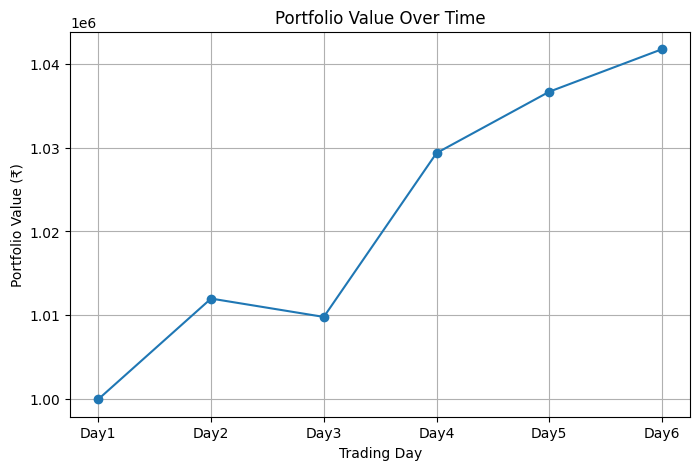


Portfolio Daily Returns:
Day2    0.011999
Day3   -0.002162
Day4    0.019346
Day5    0.007103
Day6    0.004888
dtype: float64

Daily Volatility:
0.00803419987627839

Annualised Volatility:
0.12753896913611115


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# STEP 1: Create Price DataFrame
# =====================================================

prices_df = pd.DataFrame({
    "RELIANCE": [2800, 2850, 2830, 2900, 2880, 2950],
    "INFY": [1450, 1470, 1460, 1490, 1510, 1500],
    "HDFCBANK": [1600, 1580, 1610, 1625, 1615, 1640],
    "TATAMOTORS": [520, 535, 528, 540, 555, 548]
},
index=["Day1", "Day2", "Day3", "Day4", "Day5", "Day6"])

print("Prices DataFrame:")
print(prices_df)

# =====================================================
# PART (a): Daily Percentage Returns
# =====================================================

# Formula:
# r_t = (P_t - P_(t-1)) / P_(t-1)

returns_df = prices_df.pct_change()

print("\nDaily Percentage Returns:")
print(returns_df)

# =====================================================
# PART (b): Compute Units Purchased
# =====================================================

initial_capital = 1_000_000

# Equal weights:
# w_i = 0.25

weights = np.array([0.25, 0.25, 0.25, 0.25])

# Amount invested in each asset:
# Allocation_i = Initial_Capital × Weight_i

allocation = initial_capital * weights

# Day 1 prices
day1_prices = prices_df.iloc[0]

# Units purchased:
# Units_i = Allocation_i / Price_i(Day1)

units = allocation / day1_prices

print("\nUnits Purchased:")
print(units)

# =====================================================
# Portfolio Value for Each Day
# =====================================================

# Formula:
# Portfolio_Value_t
# = Σ (Units_i × Price_i,t)

# Matrix Form:
# V = P × U

daily_portfolio_values = prices_df.dot(units)

print("\nPortfolio Value Each Day:")
print(daily_portfolio_values)

# =====================================================
# Plot Portfolio Value
# =====================================================

plt.figure(figsize=(8, 5))

plt.plot(
    daily_portfolio_values.index,
    daily_portfolio_values.values,
    marker='o'
)

plt.title("Portfolio Value Over Time")
plt.xlabel("Trading Day")
plt.ylabel("Portfolio Value (₹)")
plt.grid(True)

plt.show()

# =====================================================
# PART (c): Annualised Volatility
# =====================================================

# Portfolio Daily Returns:
# R_t = (V_t - V_(t-1)) / V_(t-1)

portfolio_returns = daily_portfolio_values.pct_change().dropna()

print("\nPortfolio Daily Returns:")
print(portfolio_returns)

# Daily Volatility:
# σ_daily = Standard Deviation of Portfolio Returns

daily_volatility = portfolio_returns.std()

print("\nDaily Volatility:")
print(daily_volatility)

# Annualised Volatility:
# σ_annual = σ_daily × √252

annual_volatility = daily_volatility * np.sqrt(252)

print("\nAnnualised Volatility:")
print(annual_volatility)

# Formulae Used

### 1. Daily Percentage Return

The daily return of an asset is calculated as

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

where:

- $P_t$ = Price on day $t$
- $P_{t-1}$ = Price on day $t-1$

---

### 2. Capital Allocation

For an equally weighted portfolio,

$$
A_i = V_0 \times w_i
$$

where:

- $A_i$ = Capital allocated to asset $i$
- $V_0$ = Initial portfolio value
- $w_i$ = Weight of asset $i$

---

### 3. Units Purchased

The number of units purchased for each asset is

$$
u_i = \frac{A_i}{P_{i,1}}
$$

where:

- $u_i$ = Units purchased of asset $i$
- $A_i$ = Capital allocated to asset $i$
- $P_{i,1}$ = Day 1 price of asset $i$

---

### 4. Portfolio Value

The portfolio value on day $t$ is

$$
V_t = \sum_{i=1}^{n} u_i P_{i,t}
$$

where:

- $V_t$ = Portfolio value on day $t$
- $u_i$ = Units held of asset $i$
- $P_{i,t}$ = Price of asset $i$ on day $t$

Using matrix multiplication,

$$
V = P \cdot U
$$

where:

- $P$ = Price matrix
- $U$ = Units vector

---

### 5. Portfolio Daily Return

The daily portfolio return is

$$
R_t = \frac{V_t - V_{t-1}}{V_{t-1}}
$$

where:

- $V_t$ = Portfolio value on day $t$
- $V_{t-1}$ = Portfolio value on day $t-1$

---

### 6. Daily Volatility

Daily volatility is the standard deviation of portfolio returns:

$$
\sigma_{\text{daily}} = \text{Std}(R_t)
$$

---

### 7. Annualised Volatility

Assuming 252 trading days in a year,

$$
\sigma_{\text{annual}}
=
\sigma_{\text{daily}}
\times
\sqrt{252}
$$

where:

- $\sigma_{\text{daily}}$ = Daily volatility
- $\sigma_{\text{annual}}$ = Annualised volatility

# Question 2

Portfolio Values from Problem 1
Day1    1.000000e+06
Day2    1.011999e+06
Day3    1.009811e+06
Day4    1.029347e+06
Day5    1.036658e+06
Day6    1.041725e+06
dtype: float64

Historical Returns
Day2    0.011999
Day3   -0.002162
Day4    0.019346
Day5    0.007103
Day6    0.004888
dtype: float64

Total Returns Used: 50

VaR (95%) = 0.023210595553212653
VaR (99%) = 0.028054086245915096

CVaR (95%) = 0.02698934100525303
CVaR (99%) = 0.028395051858196633

Maximum Drawdown = 0.16620472439189798
Peak Index : 14
Trough Index : 49


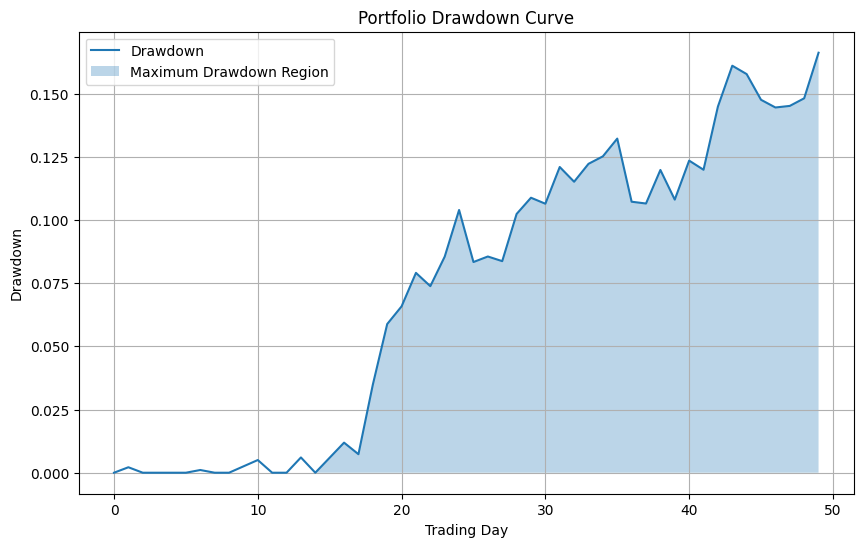

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# STEP 1: Portfolio from Problem 1
# =====================================================

prices_df = pd.DataFrame({
    "RELIANCE": [2800, 2850, 2830, 2900, 2880, 2950],
    "INFY": [1450, 1470, 1460, 1490, 1510, 1500],
    "HDFCBANK": [1600, 1580, 1610, 1625, 1615, 1640],
    "TATAMOTORS": [520, 535, 528, 540, 555, 548]
},
index=["Day1","Day2","Day3","Day4","Day5","Day6"])

initial_capital = 1_000_000

weights = np.array([0.25, 0.25, 0.25, 0.25])

# Allocation_i = V0 * w_i
allocation = initial_capital * weights

# Units_i = Allocation_i / Price_i(day1)
units = allocation / prices_df.iloc[0]

# Portfolio Value:
# V_t = Σ(u_i * P_i,t)

portfolio_values = prices_df.dot(units)

print("Portfolio Values from Problem 1")
print(portfolio_values)

# =====================================================
# STEP 2: Historical Portfolio Returns
# =====================================================

# R_t = (V_t - V_(t-1))/V_(t-1)

historical_returns = (
    portfolio_values
    .pct_change()
    .dropna()
)

print("\nHistorical Returns")
print(historical_returns)

# =====================================================
# STEP 3: Extend to 50 Trading Days
# =====================================================

np.random.seed(42)

mu = 0.001
sigma = 0.015

required_days = 50

extra_days = required_days - len(historical_returns)

synthetic_returns = np.random.normal(
    loc=mu,
    scale=sigma,
    size=extra_days
)

# Combine actual and synthetic returns

all_returns = pd.concat([
    historical_returns,
    pd.Series(synthetic_returns)
], ignore_index=True)

print("\nTotal Returns Used:", len(all_returns))

# =====================================================
# STEP 4: Historical VaR
# =====================================================

# VaR_alpha = -Percentile(R,1-alpha)

var_95 = -np.percentile(all_returns, 5)

var_99 = -np.percentile(all_returns, 1)

print("\nVaR (95%) =", var_95)
print("VaR (99%) =", var_99)

# =====================================================
# STEP 5: Historical CVaR
# =====================================================

# CVaR = Average loss beyond VaR threshold

cvar_95 = -all_returns[
    all_returns <= -var_95
].mean()

cvar_99 = -all_returns[
    all_returns <= -var_99
].mean()

print("\nCVaR (95%) =", cvar_95)
print("CVaR (99%) =", cvar_99)

# =====================================================
# STEP 6: Construct 50-Day Portfolio Path
# =====================================================

# V_t = V_(t-1)*(1+R_t)

portfolio_path = pd.Series(
    initial_capital *
    (1 + all_returns).cumprod()
)

# =====================================================
# STEP 7: Drawdown
# =====================================================

# Peak_t = max(V_1,...,V_t)

running_peak = portfolio_path.cummax()

# DD_t = (Peak_t - V_t)/Peak_t

drawdown = (
    running_peak -
    portfolio_path
) / running_peak

# =====================================================
# STEP 8: Maximum Drawdown
# =====================================================

max_drawdown = drawdown.max()

print("\nMaximum Drawdown =", max_drawdown)

# =====================================================
# STEP 9: Locate Max Drawdown Region
# =====================================================

trough_idx = drawdown.idxmax()

peak_idx = portfolio_path.iloc[:trough_idx+1].idxmax()

print("Peak Index :", peak_idx)
print("Trough Index :", trough_idx)

# =====================================================
# STEP 10: Drawdown Plot
# =====================================================

plt.figure(figsize=(10,6))

plt.plot(
    drawdown.index,
    drawdown,
    label="Drawdown"
)

plt.fill_between(
    drawdown.index[peak_idx:trough_idx+1],
    drawdown.iloc[peak_idx:trough_idx+1],
    alpha=0.3,
    label="Maximum Drawdown Region"
)

plt.title("Portfolio Drawdown Curve")
plt.xlabel("Trading Day")
plt.ylabel("Drawdown")

plt.legend()
plt.grid(True)

plt.show()

# Formulae Used

## 1. Simulated Daily Returns

Synthetic returns are generated from a normal distribution:

$$
R_t \sim N(\mu,\sigma^2)
$$

where

$$
\mu = 0.001
$$

and

$$
\sigma = 0.015
$$

---

## 2. Historical Value at Risk (VaR)

At confidence level $\alpha$,

$$
\text{VaR}_{\alpha}
=
-\text{Percentile}(R,1-\alpha)
$$

Examples:

$$
\text{VaR}_{95}
=
-\text{Percentile}(R,5)
$$

$$
\text{VaR}_{99}
=
-\text{Percentile}(R,1)
$$

---

## 3. Conditional Value at Risk (CVaR)

CVaR is the average loss beyond the VaR threshold.

$$
\text{CVaR}_{\alpha}
=
-\mathbb E[R \mid R \leq -\text{VaR}_{\alpha}]
$$

---

## 4. Portfolio Value Evolution

Using daily returns,

$$
V_t
=
V_{t-1}(1+R_t)
$$

---

## 5. Running Peak Portfolio Value

$$
\text{Peak}_t
=
\max_{s \le t}(V_s)
$$

---

## 6. Drawdown

$$
DD_t
=
\frac{\text{Peak}_t - V_t}
{\text{Peak}_t}
$$

---

## 7. Maximum Drawdown

$$
\text{MaxDD}
=
\max_t(DD_t)
$$

Equivalent form:

$$
\text{MaxDD}
=
\frac{\text{Peak}-\text{Trough}}
{\text{Peak}}
$$

# Theoretical Portion-

## Interpretation of VaR Values

### VaR at 95% Confidence Level

The 95% Value at Risk (VaR) represents the loss threshold that is expected to be exceeded on only 5% of trading days.

For example, if

$$
\text{VaR}_{95} = 0.020
$$

then there is a 95% probability that the portfolio will not lose more than 2.0% in a single day, and a 5% probability that the loss will exceed 2.0%.

---

### VaR at 99% Confidence Level

The 99% Value at Risk (VaR) represents a more extreme loss threshold that is expected to be exceeded on only 1% of trading days.

For example, if

$$
\text{VaR}_{99} = 0.035
$$

then there is a 99% probability that the portfolio will not lose more than 3.5% in a single day, and only a 1% probability that the loss will exceed 3.5%.

---

A higher confidence level leads to a larger VaR because it focuses on rarer and more severe loss events.

## Why is CVaR More Informative Than VaR for Tail Risk?

Value at Risk (VaR) identifies a loss threshold corresponding to a chosen confidence level, but it does not provide any information about the magnitude of losses beyond that threshold.

For example, if the 95% VaR is 2%, VaR tells us that only 5% of days experience losses greater than 2%. However, it does not indicate whether those losses are 2.1%, 5%, or even 15%.

Conditional Value at Risk (CVaR) addresses this limitation by measuring the average loss on days when the loss exceeds the VaR threshold.

Mathematically,

$$
\text{CVaR}_{\alpha}
=
-\mathbb{E}[R \mid R \leq -\text{VaR}_{\alpha}]
$$

Thus, CVaR provides information about the severity of extreme losses and captures the behaviour of the tail of the loss distribution.

Therefore, CVaR is considered more informative for tail risk because:

- It measures the average loss in the worst-case scenarios.
- It captures the magnitude of extreme losses.
- It provides a more complete picture of downside risk.
- It is more useful for risk management during market stress and rare adverse events.

In summary, VaR tells us **where the tail begins**, while CVaR tells us **how bad losses are once we are in the tail**.

# Question 3

# Formulae Used

## 1. Annualised Return

Let $\bar{R}_d$ denote the mean daily portfolio return.

$$
R_p = \bar{R}_d \times 252
$$

where:

- $R_p$ = Annualised portfolio return
- 252 = Number of trading days in a year

---

## 2. Annualised Volatility

$$
\sigma_p = \sigma_d \sqrt{252}
$$

where:

- $\sigma_d$ = Daily standard deviation of portfolio returns

---

## 3. Sharpe Ratio

$$
\text{Sharpe Ratio}
=
\frac{R_p-R_f}
{\sigma_p}
$$

where:

- $R_p$ = Annualised portfolio return
- $R_f$ = Risk-free rate
- $\sigma_p$ = Annualised volatility

---

## 4. Downside Returns

For Sortino Ratio, only negative returns are considered:

$$
R_t < 0
$$

---

## 5. Downside Deviation

$$
\sigma_D
=
\sqrt{
\frac{
\sum (R_t^-)^2
}
{N}
}
$$

where:

- $R_t^-$ are negative returns only
- $N$ is the total number of observations

Annualised downside deviation:

$$
\sigma_{D,\text{annual}}
=
\sigma_D \sqrt{252}
$$

---

## 6. Sortino Ratio

$$
\text{Sortino Ratio}
=
\frac{R_p-R_f}
{\sigma_{D,\text{annual}}}
$$

In [5]:
# =====================================================
# PART (a): Sharpe Ratio
# =====================================================

import numpy as np
import pandas as pd

# Risk-free rate given in question
risk_free_rate = 0.06

# Annualised Return
# Rp = mean_daily_return × 252

annual_return = all_returns.mean() * 252

# Annualised Volatility
# sigma_p = sigma_daily × sqrt(252)

annual_volatility = (
    all_returns.std()
    * np.sqrt(252)
)

# Sharpe Ratio
# Sharpe = (Rp - Rf)/sigma_p

sharpe_ratio = (
    annual_return
    - risk_free_rate
) / annual_volatility

print("Annualised Return =", annual_return)
print("Annualised Volatility =", annual_volatility)
print("Sharpe Ratio =", sharpe_ratio)

Annualised Return = -0.3013420813250305
Annualised Volatility = 0.21893191357450056
Sharpe Ratio = -1.650476969873417


## Why does Sortino penalise the portfolio less than Sharpe when upside volatility is high?

The Sharpe Ratio uses the total volatility of returns as its measure of risk. Consequently, both positive and negative deviations from the mean increase the denominator and reduce the ratio.

The Sortino Ratio only considers downside volatility, i.e., returns below the target return. Positive fluctuations are not treated as risk.

Therefore, if a portfolio experiences large positive returns but relatively few large losses, the Sharpe Ratio may decrease because of the increased overall volatility, whereas the Sortino Ratio remains comparatively higher since upside volatility is ignored.

As a result, Sortino penalises portfolios less than Sharpe when volatility is primarily driven by positive returns.

In [6]:
# =====================================================
# PART (b): Sortino Ratio
# =====================================================

# Select only negative returns

downside_returns = all_returns[
    all_returns < 0
]

# Downside Deviation
# sigma_D = sqrt(mean(negative_returns^2))

downside_deviation_daily = np.sqrt(
    np.mean(
        downside_returns ** 2
    )
)

# Annualise downside deviation

downside_deviation_annual = (
    downside_deviation_daily
    * np.sqrt(252)
)

# Sortino Ratio
# Sortino = (Rp - Rf)/sigma_D

sortino_ratio = (
    annual_return
    - risk_free_rate
) / downside_deviation_annual

print("Annualised Downside Deviation =",
      downside_deviation_annual)

print("Sortino Ratio =",
      sortino_ratio)

Annualised Downside Deviation = 0.22363612851114273
Sortino Ratio = -1.615758972982876


In [10]:
# =====================================================
# PART (c): Comparison DataFrame
# =====================================================

comparison_df = pd.DataFrame({
    "Metric": [
        "Sharpe Ratio",
        "Sortino Ratio"
    ],
    "Value": [
        sharpe_ratio,
        sortino_ratio
    ]
})

print(comparison_df)

          Metric     Value
0   Sharpe Ratio -1.650477
1  Sortino Ratio -1.615759


## Which metric is more appropriate for an asymmetrically returning strategy?

For an asymmetrically returning strategy, the Sortino Ratio is generally more appropriate.

The Sharpe Ratio treats all volatility as risk, regardless of whether the volatility arises from gains or losses. Consequently, portfolios with substantial upside fluctuations may appear less attractive even when those fluctuations are beneficial to investors.

The Sortino Ratio focuses exclusively on downside risk by considering only negative returns in the denominator. This makes it better suited for evaluating strategies with asymmetric return distributions, where upside volatility is desirable and downside volatility is the primary concern.

Therefore, for portfolios exhibiting significant positive skewness or asymmetric return behaviour, the Sortino Ratio provides a more meaningful measure of risk-adjusted performance.

# Question 4


# Formulae Used

## 1. Random Walk Price Generation

The asset price evolves according to:

$$
P_t = P_{t-1}(1+\varepsilon_t)
$$

where

$$
\varepsilon_t \sim N(0.001, 0.018)
$$

and

$$
P_0 = 1000
$$

---

## 2. Simple Moving Average (SMA)

For a window of length $n$:

$$
SMA_n(t)
=
\frac{1}{n}
\sum_{i=t-n+1}^{t}
P_i
$$

In this problem:

$$
SMA_{10}
$$

and

$$
SMA_{30}
$$

are computed.

---

## 3. Trading Signal

$$
Signal_t=
\begin{cases}
1 & \text{if } SMA_{10}>SMA_{30}\\
-1 & \text{if } SMA_{10}<SMA_{30}\\
0 & \text{otherwise}
\end{cases}
$$

where:

- $1$ = Long position
- $-1$ = Short position
- $0$ = Hold

---

## 4. Asset Daily Return

$$
R_t
=
\frac{P_t-P_{t-1}}
{P_{t-1}}
$$

---

## 5. Strategy Return

To avoid look-ahead bias, today's signal is applied to tomorrow's return:

$$
R_t^{strategy}
=
Signal_{t-1}
\times
R_t
$$

---

## 6. Cumulative Return

$$
CR_t
=
\prod_{i=1}^{t}
(1+R_i)-1
$$

---

## 7. Win Rate

$$
Win\ Rate
=
\frac{Winning\ Trades}
{Total\ Trades}
$$

---

## 8. Profit Factor

$$
Profit\ Factor
=
\frac{Total\ Profit}
{Total\ Loss}
$$

where

$$
Total\ Profit
=
\sum Positive\ Trade\ Returns
$$

and

$$
Total\ Loss
=
\left|
\sum Negative\ Trade\ Returns
\right|
$$

In [38]:
# =====================================================
# PART (a): SMA Crossover Strategy
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate random-walk prices

n_days = 200

mu = 0.001
sigma = 0.018

returns = np.random.normal(
    loc=mu,
    scale=sigma,
    size=n_days
)

prices = pd.Series(
    1000 * np.cumprod(1 + returns)
)

# Compute Moving Averages

sma_10 = prices.rolling(window=10).mean()

sma_30 = prices.rolling(window=30).mean()

# Trading Signal

signal = pd.Series(
    np.where(
        sma_10 > sma_30,
        1,
        np.where(
            sma_10 < sma_30,
            -1,
            0
        )
    ),
    index=prices.index
)

# Detect Crossovers

crossovers = signal.diff()

strategy_df = pd.DataFrame({
    "Price": prices,
    "SMA_10": sma_10,
    "SMA_30": sma_30,
    "Signal": signal,
    "Crossover": crossovers
})

print(strategy_df.head(35))

          Price       SMA_10       SMA_30  Signal  Crossover
0   1009.940855          NaN          NaN       0        NaN
1   1008.437298          NaN          NaN       0        0.0
2   1021.202494          NaN          NaN       0        0.0
3   1050.219491          NaN          NaN       0        0.0
4   1046.843286          NaN          NaN       0        0.0
5   1043.478245          NaN          NaN       0        0.0
6   1074.183459          NaN          NaN       0        0.0
7   1090.096225          NaN          NaN       0        0.0
8   1081.974421          NaN          NaN       0        0.0
9   1093.623045  1051.999882          NaN       0        0.0
10  1085.594191  1059.565215          NaN       0        0.0
11  1077.579102  1066.479396          NaN       0        0.0
12  1083.349884  1072.694135          NaN       0        0.0
13  1047.123699  1072.384556          NaN       0        0.0
14  1015.659180  1069.266145          NaN       0        0.0
15  1006.395175  1065.55

In [34]:
# =====================================================
# PART (b): Strategy Simulation
# =====================================================

initial_capital = 100000

# Asset Returns

asset_returns = prices.pct_change().fillna(0)

# Avoid look-ahead bias

strategy_returns = (
    signal.shift(1).fillna(0)
    * asset_returns
)

# Strategy cumulative return

strategy_cumulative = (
    1 + strategy_returns
).cumprod()

# Buy-and-Hold cumulative return

buy_hold_cumulative = (
    1 + asset_returns
).cumprod()

# Portfolio values

strategy_portfolio = (
    initial_capital
    * strategy_cumulative
)

buy_hold_portfolio = (
    initial_capital
    * buy_hold_cumulative
)

print("Final Strategy Value:",
      strategy_portfolio.iloc[-1])

print("Final Buy-Hold Value:",
      buy_hold_portfolio.iloc[-1])

Final Strategy Value: 120105.56148491419
Final Buy-Hold Value: 101554.68677611386


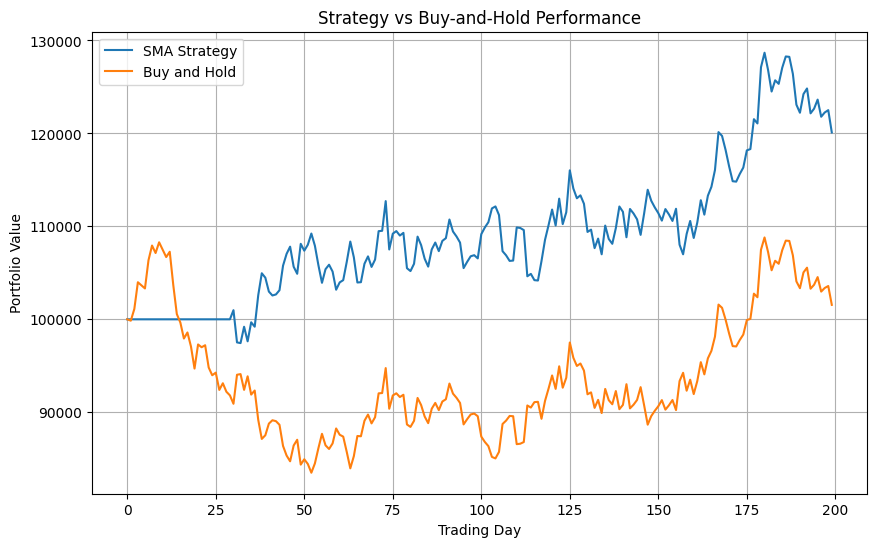

In [35]:
# =====================================================
# Plot Strategy vs Buy-and-Hold
# =====================================================

plt.figure(figsize=(10,6))

plt.plot(
    strategy_portfolio,
    label="SMA Strategy"
)

plt.plot(
    buy_hold_portfolio,
    label="Buy and Hold"
)

plt.title(
    "Strategy vs Buy-and-Hold Performance"
)

plt.xlabel("Trading Day")
plt.ylabel("Portfolio Value")

plt.legend()
plt.grid(True)

plt.show()

In [43]:
# =====================================================
# PART (c): Win Rate and Profit Factor
# =====================================================

position = signal.shift(1).fillna(0)

trade_returns = []

current_growth = 1.0

for i in range(1, len(position)):

    prev_pos = position.iloc[i - 1]
    curr_pos = position.iloc[i]

    # If a position was held during day i,
    # compound that day's strategy return

    if prev_pos != 0:

        current_growth *= (
            1 + strategy_returns.iloc[i]
        )

    # Position changed:
    # close previous trade and start new one

    if curr_pos != prev_pos:

        if prev_pos != 0:

            trade_return = (
                current_growth - 1
            )

            trade_returns.append(
                trade_return
            )

        current_growth = 1.0

# Close final trade if still open

if position.iloc[-1] != 0:

    trade_return = (
        current_growth - 1
    )

    trade_returns.append(
        trade_return
    )

trade_returns = pd.Series(
    trade_returns
)

# Winning trades

winning_trades = (
    trade_returns > 0
).sum()

# Total trades

total_trades = len(
    trade_returns
)

# Win Rate

win_rate = (
    winning_trades / total_trades
    if total_trades > 0
    else np.nan
)

# Profit Factor

gross_profit = trade_returns[
    trade_returns > 0
].sum()

gross_loss = abs(
    trade_returns[
        trade_returns < 0
    ].sum()
)

profit_factor = (
    gross_profit / gross_loss
    if gross_loss > 0
    else np.inf
)

print("Winning Trades =", winning_trades)
print("Total Trades =", total_trades)

print("Win Rate =", win_rate)

print("Gross Profit =", gross_profit)
print("Gross Loss =", gross_loss)

print("Profit Factor =", profit_factor)

Winning Trades = 4
Total Trades = 6
Win Rate = 0.6666666666666666
Gross Profit = 0.19865052242138725
Gross Loss = 0.01945131448635673
Profit Factor = 10.212704265345252


## Does a Profit Factor > 1 guarantee a good strategy?

No.

A Profit Factor greater than 1 indicates that total profits exceed total losses, which suggests that the strategy has been profitable over the observed period.

However, Profit Factor alone does not guarantee that a strategy is good because it does not account for:

- The consistency of returns.
- The size and duration of drawdowns.
- Risk-adjusted performance.
- Market regime changes.
- Transaction costs and slippage.

A strategy may have a Profit Factor greater than 1 while still experiencing large losses, high volatility, or poor risk management.

Therefore, Profit Factor should be evaluated together with other metrics such as Sharpe Ratio, Sortino Ratio, Maximum Drawdown, and Win Rate before assessing the overall quality of a trading strategy.

# Question 5

# Formulae Used

The simulated price series follows the same random walk model as Problem 4.

## 1. Price Generation

$$
P_t = P_{t-1}(1+\varepsilon_t)
$$

where

$$
\varepsilon_t \sim N(0.001,0.018)
$$

and

$$
P_0 = 500
$$

---

## 2. One-Day Return

$$
Return_{1d}
=
\frac{P_t-P_{t-1}}
{P_{t-1}}
$$

---

## 3. Simple Moving Average (SMA)

For a window of length $n$:

$$
SMA_n(t)
=
\frac{1}{n}
\sum_{i=t-n+1}^{t}
P_i
$$

In this problem:

$$
SMA_5
$$

and

$$
SMA_{20}
$$

are computed.

---

## 4. Rolling Volatility

The rolling 10-day volatility is the rolling standard deviation of returns:

$$
Volatility_{10}
=
Std(Return_{1d})
\text{ over last 10 days}
$$

---

## 5. Momentum

5-day momentum is:

$$
Momentum_5
=
P_t-P_{t-5}
$$

---

## 6. Target Variable

The target variable predicts whether tomorrow's return is positive.

$$
y_t=
\begin{cases}
1 & \text{if } r_{t+1}>0\\
0 & \text{otherwise}
\end{cases}
$$

---

## 7. Min-Max Scaling

$$
x_{scaled}
=
\frac{x-x_{min}}
{x_{max}-x_{min}}
$$

This transforms every feature into the range:

$$
[0,1]
$$

In [ ]:
# =====================================================
# Generate Simulated Price Series
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n_days = 300

mu = 0.001
sigma = 0.018

returns = np.random.normal(
    loc=mu,
    scale=sigma,
    size=n_days
)

prices = pd.Series(
    500 * np.cumprod(1 + returns),
    name="Price"
)

print(prices.head())

0    504.970427
1    504.218649
2    510.601247
3    525.109745
4    523.421643
Name: Price, dtype: float64


In [ ]:
# =====================================================
# PART (a): Feature Engineering
# =====================================================

features_df = pd.DataFrame()

# 1-Day Return

features_df["Return_1d"] = prices.pct_change()

# SMA Features

features_df["SMA_5"] = (
    prices.rolling(5).mean()
)

features_df["SMA_20"] = (
    prices.rolling(20).mean()
)

# Rolling Volatility

features_df["Volatility_10"] = (
    features_df["Return_1d"]
    .rolling(10)
    .std()
)

# Momentum

features_df["Momentum_5"] = (
    prices - prices.shift(5)
)

# Remove NaNs

features_df = (
    features_df
    .dropna()
    .reset_index(drop=True)
)

print(features_df.head())

   Return_1d       SMA_5      SMA_20  Volatility_10  Momentum_5
0  -0.024421  492.786520  518.929252       0.013596  -29.620449
1   0.027382  490.407665  518.245896       0.018731  -11.894277
2  -0.003064  489.461857  517.524862       0.018842   -4.729040
3   0.002216  488.074720  516.538956       0.018595   -6.935684
4  -0.024645  485.795724  514.222722       0.017521  -11.394980


In [ ]:
# =====================================================
# PART (b): Create Target Variable
# =====================================================

# Tomorrow's return

future_return = (
    prices.pct_change()
    .shift(-1)
)

target = (
    future_return > 0
).astype(int)

# Align target with feature matrix

target = target.iloc[
    len(prices) - len(features_df):
].reset_index(drop=True)

# Add target column

features_df["Target"] = target

# Remove final NaN target row

features_df = features_df.dropna()

print(features_df.head())

   Return_1d       SMA_5      SMA_20  Volatility_10  Momentum_5  Target
0  -0.024421  492.786520  518.929252       0.013596  -29.620449       1
1   0.027382  490.407665  518.245896       0.018731  -11.894277       0
2  -0.003064  489.461857  517.524862       0.018842   -4.729040       1
3   0.002216  488.074720  516.538956       0.018595   -6.935684       0
4  -0.024645  485.795724  514.222722       0.017521  -11.394980       0


Target
1    151
0    130
Name: count, dtype: int64


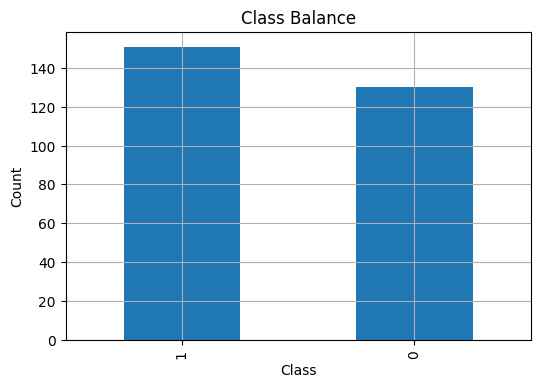

In [ ]:
# =====================================================
# Class Balance
# =====================================================

class_balance = (
    features_df["Target"]
    .value_counts()
)

print(class_balance)

plt.figure(figsize=(6,4))

class_balance.plot(
    kind="bar"
)

plt.title("Class Balance")
plt.xlabel("Class")
plt.ylabel("Count")

plt.grid(True)

plt.show()

In [ ]:
# =====================================================
# PART (c): Manual Min-Max Scaling
# =====================================================

X = features_df.drop(
    columns=["Target"]
)

X_scaled = (
    X - X.min()
) / (
    X.max() - X.min()
)

scaled_df = X_scaled.copy()

scaled_df["Target"] = (
    features_df["Target"]
)

print(scaled_df.head())

   Return_1d     SMA_5    SMA_20  Volatility_10  Momentum_5  Target
0   0.257818  0.316328  0.461523       0.226798    0.233485       1
1   0.663507  0.305072  0.457837       0.546655    0.362831       0
2   0.425076  0.300597  0.453948       0.553528    0.415115       1
3   0.466422  0.294034  0.448630       0.538124    0.399013       0
4   0.256064  0.283251  0.436135       0.471264    0.366474       0


## Why is Feature Scaling Important Before Applying KNN?

K-Nearest Neighbours (KNN) classifies observations using distance measures such as Euclidean distance.

Features with larger numerical ranges contribute more heavily to the distance calculation and may dominate features with smaller ranges.

As a result, the model may incorrectly treat large-scale features as more important, even when they are not.

Min-Max scaling transforms all features to a common range between 0 and 1, ensuring that each feature contributes proportionally to the distance computation.

Therefore, feature scaling improves the fairness and effectiveness of KNN classification.

# Question 6

# Formulae Used

## 1. Euclidean Distance

The distance between two observations

$$
x_1=(x_{11},x_{12},...,x_{1p})
$$

and

$$
x_2=(x_{21},x_{22},...,x_{2p})
$$

is:

$$
d(x_1,x_2)
=
\sqrt{
\sum_{j=1}^{p}
(x_{1j}-x_{2j})^2
}
$$

where:

- $p$ = Number of features

---

## 2. K-Nearest Neighbours (KNN)

For a test observation:

1. Compute distances to all training observations.
2. Select the $k$ smallest distances.
3. Find the majority class among the selected neighbours.
4. Assign that class as the prediction.

---

## 3. Accuracy

$$
Accuracy
=
\frac{
Number\ of\ Correct\ Predictions
}{
Total\ Predictions
}
$$

---

## 4. Confusion Matrix

|                | Predicted 1 | Predicted 0 |
|----------------|------------|------------|
| Actual 1 | TP | FN |
| Actual 0 | FP | TN |

where:

- TP = True Positives
- TN = True Negatives
- FP = False Positives
- FN = False Negatives

---

## 5. Precision

$$
Precision
=
\frac{TP}
{TP+FP}
$$

Precision measures the proportion of positive predictions that are actually correct.

---

## 6. Recall

$$
Recall
=
\frac{TP}
{TP+FN}
$$

Recall measures the proportion of actual positive observations correctly identified.

In [ ]:
# =====================================================
# Data from Problem 5
# =====================================================

X = scaled_df.drop(columns=["Target"]).values
y = scaled_df["Target"].values

# 80-20 train-test split

split_idx = int(0.8 * len(X))

X_train = X[:split_idx]
X_test = X[split_idx:]

y_train = y[:split_idx]
y_test = y[split_idx:]

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 224
Testing Samples: 57


In [ ]:
# =====================================================
# PART (a): KNN From Scratch
# =====================================================

import numpy as np

def euclidean_distance(x1, x2):
    """
    d(x1,x2) = sqrt(sum((x1-x2)^2))
    """
    return np.sqrt(np.sum((x1 - x2) ** 2))


def knn_predict(X_train, y_train, X_test, k):

    predictions = []

    for test_point in X_test:

        distances = np.array([
            euclidean_distance(test_point, train_point)
            for train_point in X_train
        ])

        nearest_indices = np.argsort(distances)[:k]

        nearest_labels = y_train[nearest_indices]

        prediction = np.bincount(
            nearest_labels
        ).argmax()

        predictions.append(prediction)

    return np.array(predictions)

In [ ]:
# =====================================================
# PART (b): Accuracy vs k
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

k_values = [3, 5, 7, 11, 15]

accuracies = []

for k in k_values:

    y_pred = knn_predict(
        X_train,
        y_train,
        X_test,
        k
    )

    accuracy = np.mean(
        y_pred == y_test
    )

    accuracies.append(accuracy)

    print(
        f"k = {k}, Accuracy = {accuracy:.4f}"
    )

results_df = pd.DataFrame({
    "k": k_values,
    "Accuracy": accuracies
})

print("\nAccuracy Table")
print(results_df)

k = 3, Accuracy = 0.5789
k = 5, Accuracy = 0.5088
k = 7, Accuracy = 0.5439
k = 11, Accuracy = 0.4561
k = 15, Accuracy = 0.6140

Accuracy Table
    k  Accuracy
0   3  0.578947
1   5  0.508772
2   7  0.543860
3  11  0.456140
4  15  0.614035


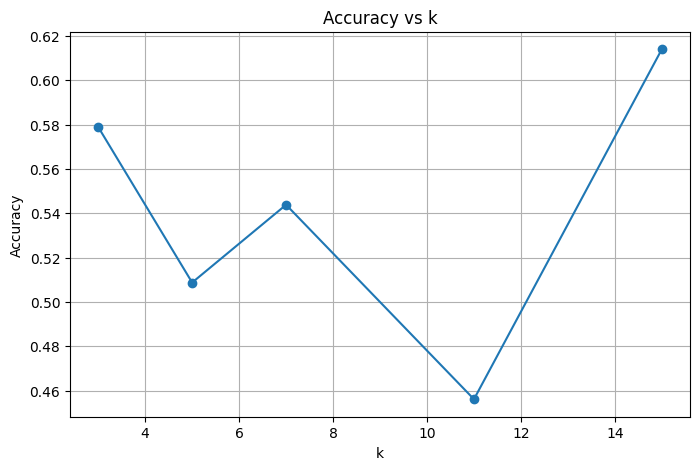

Best k = 15
Best Accuracy = 0.6140350877192983


In [ ]:
# =====================================================
# Accuracy vs k Plot
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.title("Accuracy vs k")
plt.xlabel("k")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()
# =====================================================
# Best k
# =====================================================

best_idx = np.argmax(accuracies)

best_k = k_values[best_idx]

print("Best k =", best_k)
print("Best Accuracy =", accuracies[best_idx])

In [ ]:
# =====================================================
# Confusion Matrix
# =====================================================

y_pred_best = knn_predict(
    X_train,
    y_train,
    X_test,
    best_k
)

TP = np.sum(
    (y_test == 1) &
    (y_pred_best == 1)
)

TN = np.sum(
    (y_test == 0) &
    (y_pred_best == 0)
)

FP = np.sum(
    (y_test == 0) &
    (y_pred_best == 1)
)

FN = np.sum(
    (y_test == 1) &
    (y_pred_best == 0)
)

confusion_matrix = pd.DataFrame(
    [[TP, FN],
     [FP, TN]],
    index=["Actual 1", "Actual 0"],
    columns=["Predicted 1",
             "Predicted 0"]
)

print(confusion_matrix)

precision = TP / (TP + FP)

recall = TP / (TP + FN)

print("\nPrecision =", precision)
print("Recall =", recall)

          Predicted 1  Predicted 0
Actual 1           21            7
Actual 0           15           14

Precision = 0.5833333333333334
Recall = 0.75


## In Trading, Which Metric is More Important When False Positives Are Costly?

When false positives are costly, **Precision** is generally more important than Recall.

A false positive occurs when the model predicts that the price will rise (class 1) but the price actually falls or remains unchanged.

Such errors may lead to entering losing trades and incurring transaction costs or capital losses.

Precision measures:

$$
Precision=
\frac{TP}{TP+FP}
$$

A high Precision value indicates that when the model predicts a price increase, it is usually correct.

Recall measures:

$$
Recall=
\frac{TP}{TP+FN}
$$

and focuses on finding as many positive opportunities as possible, even at the expense of generating more false positives.

Therefore, when incorrect buy signals are expensive, Precision is typically the more important metric.

# Question 7

# Formulae Used

## 1. Linear Regression Model

The linear regression model assumes:

$$
\hat y = X\beta
$$

where:

- $X$ = Feature matrix
- $\beta$ = Coefficient vector
- $\hat y$ = Predicted target

---

## 2. Normal Equation

The closed-form solution for the coefficient vector is:

$$
\hat\beta
=
(X^TX)^{-1}X^Ty
$$

A bias column of ones is added to the feature matrix before computing the solution.

---

## 3. Mean Squared Error (MSE)

$$
MSE
=
\frac1n
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
$$

where:

- $y_i$ = Actual value
- $\hat y_i$ = Predicted value

---

## 4. Coefficient of Determination ($R^2$)

$$
R^2
=
1
-
\frac{
\sum_{i=1}^{n}(y_i-\hat y_i)^2
}{
\sum_{i=1}^{n}(y_i-\bar y)^2
}
$$

where:

- $\bar y$ = Mean of actual target values

---

## 5. Batch Gradient Descent

The coefficient update rule is:

$$
\beta
\leftarrow
\beta
-
\frac{\eta}{n}
X^T(X\beta-y)
$$

where:

- $\eta$ = Learning rate
- $n$ = Number of observations

---

## 6. Loss Function

The loss function minimized by Gradient Descent is:

$$
J(\beta)
=
\frac1n
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
$$

In [ ]:
# =====================================================
# Create Continuous Target
# =====================================================

import numpy as np
import pandas as pd

# Use Problem 5 price series

future_return = (
    prices.pct_change()
    .shift(-1)
)

# Align with scaled_df rows

y_reg = future_return.iloc[
    len(prices) - len(scaled_df):
].reset_index(drop=True)

# Remove final NaN

scaled_reg_df = scaled_df.copy()

scaled_reg_df["Future_Return"] = y_reg

scaled_reg_df = scaled_reg_df.dropna()

print(scaled_reg_df.head())

   Return_1d     SMA_5    SMA_20  Volatility_10  Momentum_5  Target  \
0   0.257818  0.316328  0.461523       0.226798    0.233485       1   
1   0.663507  0.305072  0.457837       0.546655    0.362831       0   
2   0.425076  0.300597  0.453948       0.553528    0.415115       1   
3   0.466422  0.294034  0.448630       0.538124    0.399013       0   
4   0.256064  0.283251  0.436135       0.471264    0.366474       0   

   Future_Return  
0       0.027382  
1      -0.003064  
2       0.002216  
3      -0.024645  
4      -0.008799  


In [ ]:
# =====================================================
# Train-Test Split
# =====================================================

X = scaled_reg_df[
    ["Return_1d",
     "SMA_5",
     "SMA_20",
     "Volatility_10",
     "Momentum_5"]
].values

y = scaled_reg_df["Future_Return"].values

split_idx = int(0.8 * len(X))

X_train = X[:split_idx]
X_test = X[split_idx:]

y_train = y[:split_idx]
y_test = y[split_idx:]

In [ ]:
# =====================================================
# Linear Regression using Normal Equation
# =====================================================

# Add bias column

X_train_bias = np.c_[
    np.ones(len(X_train)),
    X_train
]

X_test_bias = np.c_[
    np.ones(len(X_test)),
    X_test
]

# beta = (X'X)^(-1) X'y

beta = np.linalg.inv(
    X_train_bias.T @ X_train_bias
) @ (
    X_train_bias.T @ y_train
)

print("Learned Coefficients\n")

feature_names = [
    "Intercept",
    "Return_1d",
    "SMA_5",
    "SMA_20",
    "Volatility_10",
    "Momentum_5"
]

for name, coef in zip(feature_names, beta):
    print(f"{name}: {coef:.6f}")

Learned Coefficients

Intercept: 0.011296
Return_1d: -0.005581
SMA_5: 0.019421
SMA_20: -0.017373
Volatility_10: -0.003803
Momentum_5: -0.014065


## Interpretation of Coefficients

For each feature:

- A positive coefficient indicates that increasing the feature tends to increase the predicted next-day return.
- A negative coefficient indicates that increasing the feature tends to decrease the predicted next-day return.
- Larger absolute values indicate stronger influence on the prediction.
- The intercept represents the predicted return when all feature values are zero.

In [ ]:
# =====================================================
# Predictions
# =====================================================

y_pred = X_test_bias @ beta

# =====================================================
# MSE
# =====================================================

mse = np.mean(
    (y_test - y_pred) ** 2
)

# =====================================================
# R²
# =====================================================

r2 = 1 - (
    np.sum((y_test - y_pred) ** 2)
    /
    np.sum(
        (y_test - np.mean(y_test)) ** 2
    )
)

print("MSE =", mse)
print("R² =", r2)

MSE = 0.0003528069631378821
R² = 0.02731644896413632


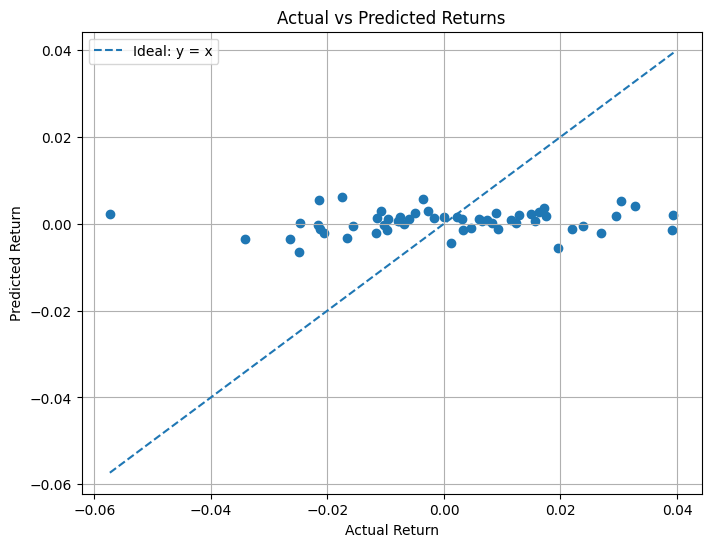

In [ ]:
# =====================================================
# Actual vs Predicted Scatter Plot
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

min_val = min(
    y_test.min(),
    y_pred.min()
)

max_val = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Ideal: y = x"
)

plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")

plt.title(
    "Actual vs Predicted Returns"
)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# =====================================================
# Batch Gradient Descent
# =====================================================

eta = 0.01
iterations = 1000

beta_gd = np.zeros(
    X_train_bias.shape[1]
)

n = len(X_train)

loss_history = []

for _ in range(iterations):

    predictions = (
        X_train_bias @ beta_gd
    )

    errors = (
        predictions - y_train
    )

    gradient = (
        X_train_bias.T @ errors
    ) / n

    beta_gd = (
        beta_gd
        - eta * gradient
    )

    mse_loss = np.mean(
        errors ** 2
    )

    loss_history.append(
        mse_loss
    )

print("Gradient Descent Coefficients\n")

for name, coef in zip(
    feature_names,
    beta_gd
):
    print(
        f"{name}: {coef:.6f}"
    )

Gradient Descent Coefficients

Intercept: 0.001959
Return_1d: -0.000871
SMA_5: 0.000361
SMA_20: 0.000184
Volatility_10: -0.000382
Momentum_5: -0.000875


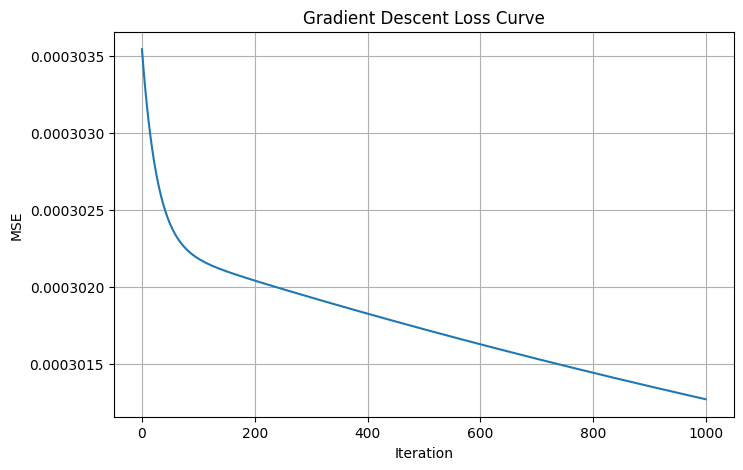

In [ ]:
# =====================================================
# Loss Curve
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title(
    "Gradient Descent Loss Curve"
)

plt.xlabel("Iteration")
plt.ylabel("MSE")

plt.grid(True)

plt.show()

## Do the coefficients converge to the Normal Equation solution?

The Normal Equation computes the exact closed-form solution for linear regression.

Batch Gradient Descent iteratively updates the coefficients to minimise the same Mean Squared Error objective function.

With a sufficiently small learning rate and enough iterations, the Gradient Descent coefficients should approach the Normal Equation coefficients. Small differences may remain due to finite iterations and numerical precision.

Therefore, the two methods are expected to produce very similar coefficient estimates when Gradient Descent converges successfully.

# Question 8

# Formulae Used

## 1. Linear Regression Prediction

The expected return of asset $i$ is predicted as

$$
\hat{\mu}_i
=
X_i \hat{\beta}
$$

where:

- $X_i$ = Feature vector for asset $i$
- $\hat{\beta}$ = Learned regression coefficients

---

## 2. Portfolio Weights

Only assets with positive predicted returns receive capital allocation.

$$
w_i
=
\frac{
\max(\hat{\mu}_i,0)
}{
\sum_j
\max(\hat{\mu}_j,0)
}
$$

Properties:

$$
w_i \ge 0
$$

and

$$
\sum_i w_i = 1
$$

---

## 3. Portfolio Return

The portfolio return at time $t$ is

$$
R_{p,t}
=
\sum_i w_i R_{i,t}
$$

where:

- $w_i$ = Portfolio weight of asset $i$
- $R_{i,t}$ = Return of asset $i$

---

## 4. Equal-Weight Portfolio

For four assets,

$$
w_i=\frac14
$$

for all assets.

---

## 5. Cumulative Return

$$
CR_t
=
\prod_{k=1}^{t}
(1+R_k)-1
$$

This measures total portfolio growth over time.

In [ ]:
# =====================================================
# PART (a): Predict Expected Returns
# =====================================================

predicted_returns = []
asset_names = []

for asset in prices_df.columns:

    asset_return = (
        prices_df[asset]
        .pct_change()
        .dropna()
        .mean()
    )

    predicted_returns.append(asset_return)
    asset_names.append(asset)

mu_hat = np.array(predicted_returns)

print("Predicted Returns Array:")
print(mu_hat)

Predicted Returns Array:
[0.01059672 0.00686773 0.00502603 0.0107309 ]


In [ ]:
# =====================================================
# PART (b): Portfolio Weights
# =====================================================

weights = (
    np.maximum(mu_hat, 0)
    /
    np.maximum(mu_hat, 0).sum()
)

weights_df = pd.DataFrame({
    "Asset": asset_names,
    "Weight": weights
})

print(weights_df)

print("\nSum of weights =", weights.sum())

        Asset    Weight
0    RELIANCE  0.318973
1        INFY  0.206726
2    HDFCBANK  0.151289
3  TATAMOTORS  0.323012

Sum of weights = 1.0


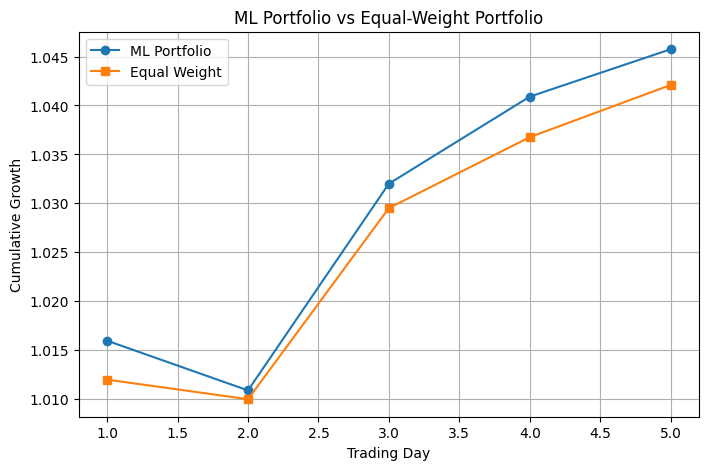

In [ ]:
# =====================================================
# PART (c): Backtest
# =====================================================

asset_returns = (
    prices_df
    .pct_change()
    .dropna()
)

# ML Portfolio

ml_returns = asset_returns @ weights

# Equal Weight Portfolio

equal_weights = np.repeat(
    0.25,
    len(prices_df.columns)
)

equal_returns = (
    asset_returns
    @ equal_weights
)

# Cumulative Returns

ml_cumulative = (
    1 + ml_returns
).cumprod()

equal_cumulative = (
    1 + equal_returns
).cumprod()

plt.figure(figsize=(8,5))

plt.plot(
    ml_cumulative,
    marker="o",
    label="ML Portfolio"
)

plt.plot(
    equal_cumulative,
    marker="s",
    label="Equal Weight"
)

plt.title(
    "ML Portfolio vs Equal-Weight Portfolio"
)

plt.xlabel("Trading Day")
plt.ylabel("Cumulative Growth")

plt.legend()
plt.grid(True)

plt.show()

## Does the ML-Driven Portfolio Outperform?

Compare the final cumulative return values from the plot.

- If the ML portfolio curve ends above the equal-weight curve, the ML-driven allocation outperformed.
- Otherwise, the equal-weight portfolio performed better over the available test period.

### One Limitation

This approach depends entirely on the accuracy of the predicted returns. If the Linear Regression model produces poor forecasts, the resulting portfolio weights may be suboptimal and lead to inferior performance.

# Question 9

# Formulae Used

## 1. k-Fold Cross Validation

The dataset is divided into $k$ approximately equal folds.

For each iteration:

- One fold is used as the validation set.
- The remaining $k-1$ folds are used for training.

The process is repeated $k$ times.

---

## 2. Mean Accuracy

$$
\bar A
=
\frac1k
\sum_{i=1}^{k}
A_i
$$

where:

- $A_i$ = Accuracy of fold $i$

---

## 3. Standard Deviation of Accuracy

$$
\sigma_A
=
\sqrt{
\frac1k
\sum_{i=1}^{k}
(A_i-\bar A)^2
}
$$

This measures the stability of model performance across folds.

---

## 4. KNN Accuracy

$$
Accuracy
=
\frac{
Number\ of\ Correct\ Predictions
}{
Total\ Predictions
}
$$

---

## 5. Linear Regression Metrics

### Mean Squared Error

$$
MSE
=
\frac1n
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
$$

### Coefficient of Determination

$$
R^2
=
1-
\frac{
\sum (y_i-\hat y_i)^2
}{
\sum (y_i-\bar y)^2
}
$$

In [ ]:
# =====================================================
# PART (a): 5-Fold Cross Validation
# =====================================================

# Dataset from Problem 5

X = scaled_df.drop(
    columns=["Target"]
).values

y = scaled_df["Target"].values

# Create folds

X_folds = np.array_split(X, 5)
y_folds = np.array_split(y, 5)

k_values = [3, 7, 11]

cv_results = {}

for k in k_values:

    fold_accuracies = []

    for i in range(5):

        X_valid = X_folds[i]
        y_valid = y_folds[i]

        X_train = np.vstack(
            [X_folds[j]
             for j in range(5)
             if j != i]
        )

        y_train = np.hstack(
            [y_folds[j]
             for j in range(5)
             if j != i]
        )

        y_pred = knn_predict(
            X_train,
            y_train,
            X_valid,
            k
        )

        accuracy = np.mean(
            y_pred == y_valid
        )

        fold_accuracies.append(
            accuracy
        )

    cv_results[k] = {
        "Mean Accuracy":
        np.mean(fold_accuracies),

        "Std Accuracy":
        np.std(fold_accuracies)
    }

cv_df = pd.DataFrame(
    cv_results
).T

print(cv_df)

    Mean Accuracy  Std Accuracy
3        0.473684      0.098274
7        0.491353      0.062051
11       0.502068      0.050809


In [ ]:
# =====================================================
# Best k
# =====================================================

best_k = cv_df[
    "Mean Accuracy"
].idxmax()

print("Best k =", best_k)

Best k = 11


In [ ]:
# =====================================================
# Model Comparison Table
# =====================================================

comparison_df = pd.DataFrame({
    "Model": [
        "KNN Classifier",
        "Linear Regression"
    ],

    "Accuracy/R²": [
        cv_df.loc[
            best_k,
            "Mean Accuracy"
        ],
        r2
    ],

    "MSE/N.A.": [
        "N.A.",
        mse
    ],

    "Best Param": [
        f"k = {best_k}",
        "Normal Equation"
    ]
})

print(comparison_df)

               Model  Accuracy/R²  MSE/N.A.       Best Param
0     KNN Classifier     0.502068      N.A.           k = 11
1  Linear Regression     0.027316  0.000353  Normal Equation


## Part (c)

## Which Model Would You Deploy?

The preferred model would generally be the one that demonstrates stronger out-of-sample performance and greater stability.

If the KNN classifier achieves consistently higher validation accuracy across folds, it may be preferred for directional prediction. If the Linear Regression model provides meaningful predictive power with a satisfactory $R^2$ value and low MSE, it may be preferred for return forecasting and portfolio construction.

The final decision should be based on the evaluation metrics obtained in Parts (a) and (b).

---

## Risk 1: Overfitting

Overfitting occurs when a model learns patterns that are specific to the training data but do not generalise to unseen market conditions.

As a result, historical performance may appear strong while future performance deteriorates significantly.

---

## Risk 2: Look-Ahead Bias

Look-ahead bias occurs when future information accidentally influences the training process.

This creates unrealistically optimistic results because the model is effectively using information that would not have been available at the time of prediction.

Such models often fail when deployed in live trading environments.

# Question 10

### (a) Diversification

Portfolio variance depends not only on the individual asset variances but also on the correlations between assets. When assets have low or negative correlations, the covariance terms become smaller, reducing overall portfolio risk. Negative correlations can partially offset losses in one asset with gains in another. Therefore, diversification reduces risk without necessarily reducing expected return.

### (b) Technical vs Fundamental Analysis in ML

The KNN model in this assignment uses technical indicators derived from historical prices. Fundamental features such as P/E ratio, debt-to-equity ratio, and earnings growth could also be included. These values can be obtained from financial statements or financial databases and added to the feature matrix. Combining technical and fundamental information may improve predictive performance.

### (c) The Curse of Dimensionality

As the number of features increases, distances between observations become less meaningful. This makes it harder for KNN to identify truly similar neighbours, reducing prediction accuracy. Financial datasets may also contain noisy or irrelevant features. Dimensionality reduction techniques such as PCA can help mitigate this problem.

### (d) Overfitting in Backtesting

A large gap between backtest and live performance may indicate overfitting. Possible causes include look-ahead bias, survivorship bias, and data snooping. Look-ahead bias can be checked using strictly time-ordered train-test splits, while survivorship bias requires datasets containing delisted securities. Data snooping can be detected through out-of-sample or walk-forward validation.

### (e) Linear Regression Assumptions

Financial returns often violate the i.i.d. assumption of Linear Regression. One common issue is autocorrelation, where prediction errors are related across time. Another is heteroscedasticity, where error variance changes during periods of high and low market volatility. These violations can reduce the reliability of coefficient estimates and predictions.